<a href="https://colab.research.google.com/github/Ankit5288-commits/Hotel-Booking-Feature-Engineering/blob/main/FeatureEngineering_Capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
from numpy.random.mtrand import rand
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
# loading the datatset
url="https://raw.githubusercontent.com/swapnilsaurav/Dataset/refs/heads/master/hotel_bookings.csv"
df=pd.read_csv(url)
# random data sampling to reduce processing time while keeping dataset same
df_sample=df.sample(n=10000,random_state=42).reset_index(drop=True)
# finding the most missing values column
most_missing_col = df.isnull().sum().sort_values(ascending=False)
print(f"The column with the most missing values is: '{most_missing_col}'")

df=df.drop(["company","agent"],axis=1)
df["children"]=df["children"].fillna(0)
df["country"]=df["country"].fillna("unkown")

The column with the most missing values is: 'company                           112593
agent                              16353
meal                               13703
babies                             13517
deposit_type                        9842
children                            2461
country                              502
assigned_room_type                    14
arrival_date_day_of_month             14
market_segment                        14
adults                                14
distribution_channel                  14
reserved_room_type                    14
is_repeated_guest                     14
stays_in_weekend_nights               14
arrival_date_week_number              14
stays_in_week_nights                  14
reservation_status                    14
days_in_waiting_list                  14
customer_type                         14
adr                                   14
required_car_parking_spaces           14
previous_bookings_not_canceled        14
booking_chan

# task-1 Baseline Model

In [26]:
from numpy.random import RandomState
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
# copying the data said to prevent original data from being manipulated
df_copy=df.copy()

num_cols=df_copy.select_dtypes(include="number").columns
df_copy[num_cols]=df_copy[num_cols].fillna(df_copy[num_cols].median()) #fill up the missing values with median
num_cols2=df_copy.select_dtypes(include=["object"]).columns
for col in num_cols2:
  df_copy[col]=LabelEncoder().fit_transform(df_copy[col]) # encoding the non-numerical values


X=df_copy.drop("is_canceled",axis=1) #clues for processing
Y=df_copy["is_canceled"] #ans
Xtrain,Xtest,Ytrain,Ytest=train_test_split(X,Y,test_size=0.2,random_state=42) # splitting the data in training and testing set

model=LogisticRegression(max_iter=1000)
model.fit(Xtrain,Ytrain)
Ypredict=model.predict(Xtest)
#baseline scores
print("\nBaseline Results\n")
results_table = pd.DataFrame({"Metric": ["Accuracy", "ROC-AUC"],"Score": [
        round(accuracy_score(Ytest, Ypredict), 4),
        round(roc_auc_score(Ytest, Ypredict), 4)]})
print(results_table.to_string(index=False))
print("\nConfusion matrix:\n",confusion_matrix(Ytest,Ypredict))


Baseline Results

  Metric  Score
Accuracy 0.8152
 ROC-AUC 0.7949

Confusion matrix:
 [[13065  1842]
 [ 2571  6400]]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# task-2 Curse of dimensionality

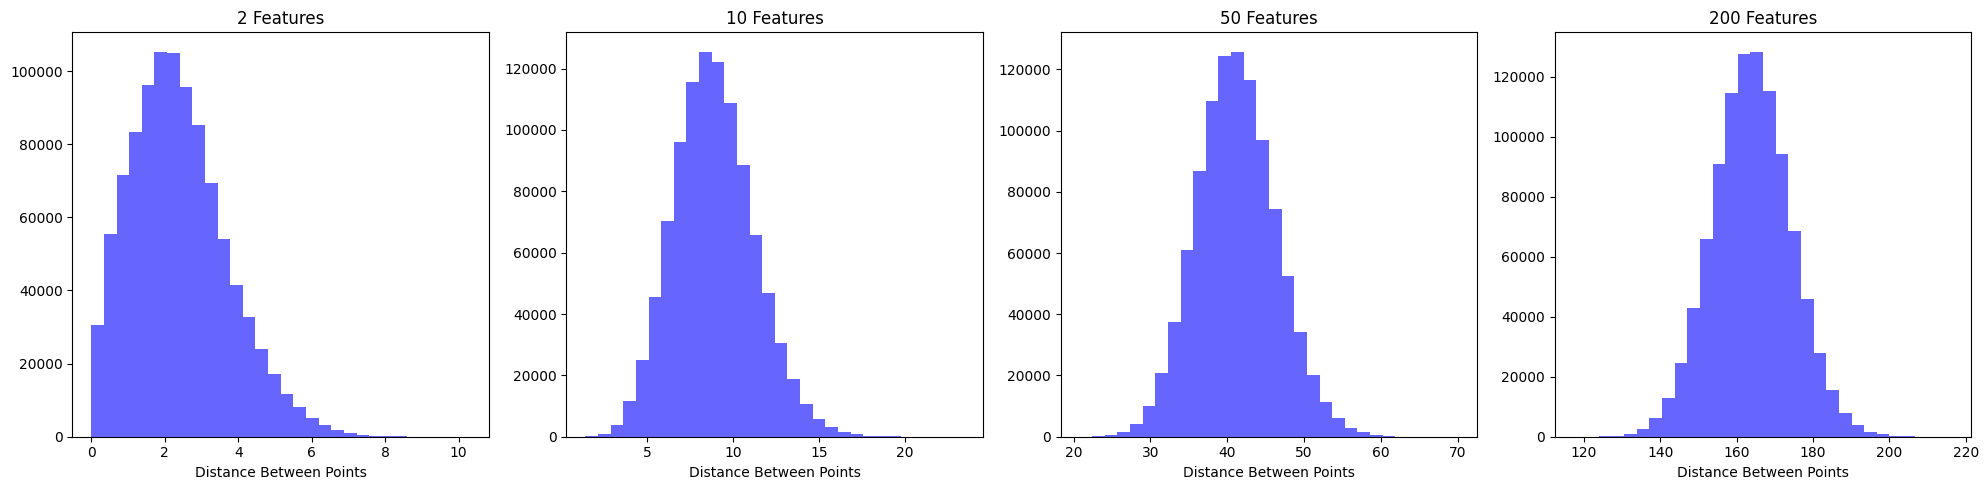

In [27]:
from sklearn.datasets import make_classification
from sklearn.metrics.pairwise import euclidean_distances
dim=[2,10,50,200] #dimensions to check
fig,axes=plt.subplots(1,4,figsize=(20,5))

for i,d in enumerate(dim):
  Xfake,_=make_classification(n_samples=1000,n_features=d,n_informative=d,n_redundant=0,random_state=42)
  #creating random data set of fake data and using Euclidean distance
  dist=euclidean_distances(Xfake).flatten()
  dist=dist[dist>0]
  axes[i].hist(dist, bins=30, color='blue', alpha=0.6)
  axes[i].set_title(f'{d} Features')
  axes[i].set_xlabel('Distance Between Points')


plt.tight_layout()
plt.show()

# task-3 Numeric Preprocessing


Summary Statistics Change

      Original ADR  MinMax ADR  Std. ADR  Robust ADR
Mean      101.8298      0.0200    0.0000      0.1291
Std        50.5348      0.0093    1.0000      0.8910
IQR        56.7200      0.0105    1.1224      1.0000




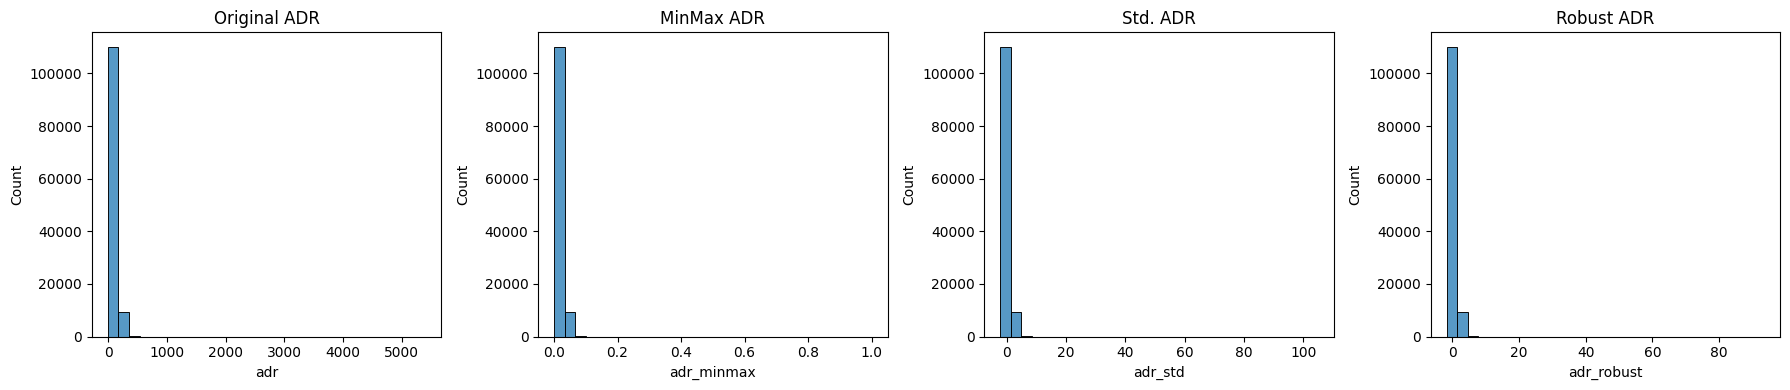

In [28]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
df_copy2=df.copy()
#6 Features cols
cols = ['lead_time', 'adr', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'total_of_special_requests']
#binning
df_copy2["lead_time_bins"]=pd.qcut(df_copy2['lead_time'],q=4,labels=['Short', 'Med', 'Long', 'VeryLong'])
df_copy2["ADR_bins"]=pd.cut(df_copy2["adr"],bins=3,labels=["Low","Medium","High"]) # avg daily rate
# Binarization
df_copy2["high_value_customers"]=np.where(df_copy2["adr"]>100,1,0)
df_copy2["has_special_requests"] = np.where(df_copy2["total_of_special_requests"] > 0, 1, 0)
#customers which makes special request a generally much more engaged and less likely to quit


#mean,std,iqr
def stats(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    return {"Mean": series.mean(), "Std": series.std(), "IQR": iqr}

#3 type-scaling w.r.t average daily rate
for i in cols:
    df_copy2[f"{i}_minmax"] = MinMaxScaler().fit_transform(df_copy2[[i]])
    df_copy2[f"{i}_std"] = StandardScaler().fit_transform(df_copy2[[i]])
    df_copy2[f"{i}_robust"] = RobustScaler().fit_transform(df_copy2[[i]])


stats_df = pd.DataFrame({
    "Original ADR": pd.Series(stats(df_copy2["adr"])).round(4),
    "MinMax ADR": pd.Series(stats(df_copy2["adr_minmax"])).round(4),
    "Std. ADR": pd.Series(stats(df_copy2["adr_std"])).round(4),
    "Robust ADR": pd.Series(stats(df_copy2["adr_robust"])).round(4)
})
print("\nSummary Statistics Change\n")
print(stats_df)
print("\n")

#plotting the figures
fig,axes=plt.subplots(1,4,figsize=(18,4))
sns.histplot(df_copy2["adr"],ax=axes[0], bins=30).set_title("Original ADR")
sns.histplot(df_copy2["adr_minmax"],ax=axes[1], bins=30).set_title("MinMax ADR")
sns.histplot(df_copy2["adr_std"],ax=axes[2], bins=30).set_title("Std. ADR")
sns.histplot(df_copy2["adr_robust"],ax=axes[3], bins=30).set_title("Robust ADR")
plt.tight_layout()
plt.show()

# task-4 proximity metrices and impact

In [29]:
from sklearn.neighbors import KNeighborsClassifier

df_copy3=df[["adr","lead_time","is_canceled"]].copy()
df_copy3=df_copy3.dropna() #droppping empty table values from complete table to make sure x and y match

Xknn=df_copy3[["adr","lead_time"]]
Yknn=df_copy3["is_canceled"]

#dataset splitting
XtrainK,XtestK,YtrainK,YtestK=train_test_split(Xknn,Yknn,test_size=0.2,random_state=42)
#unscaled Knn
knn_unscaled = KNeighborsClassifier(metric='euclidean')
knn_unscaled.fit(XtrainK,YtrainK)
Ypredict_UnscaledK = knn_unscaled.predict(XtestK)
print(f"Unscaled KNN-euclidean accuracy: {accuracy_score(YtestK,Ypredict_UnscaledK): .4f}")

#standard scaled Knn
scaler1=StandardScaler()
Xtrain_Std_scaled = scaler1.fit_transform(XtrainK)
Xtest_Std_scaled = scaler1.transform(XtestK)

knn_scaled = KNeighborsClassifier(metric='euclidean')
knn_scaled.fit(Xtrain_Std_scaled,YtrainK)

Ypredict_scaledK = knn_scaled.predict(Xtest_Std_scaled)
print(f"Standard-Scale KNN-euclidean accuracy: {accuracy_score(YtestK,Ypredict_scaledK): .4f}")

#robust scalled knn
scaler2=RobustScaler()
Xtrain_rob_scaled = scaler2.fit_transform(XtrainK)
Xtest_rob_scaled = scaler2.transform(XtestK)

knn_scaled = KNeighborsClassifier(metric='euclidean')
knn_scaled.fit(Xtrain_rob_scaled,YtrainK)

Ypredict_scaledK = knn_scaled.predict(Xtest_rob_scaled)
print(f"Robust-Scale KNN-euclidean accuracy: {accuracy_score(YtestK,Ypredict_scaledK): .4f}")

#robust scalled manhattan comparison with euclid
knn_manhattan = KNeighborsClassifier(metric='manhattan')
knn_manhattan.fit(Xtrain_rob_scaled,YtrainK)
Ypredict_manhattan = knn_manhattan.predict(Xtest_rob_scaled)
print(f"Robust-Scale KNN-manhattan accuracy: {accuracy_score(YtestK, Ypredict_manhattan):.4f}")

Unscaled KNN-euclidean accuracy:  0.7496
Standard-Scale KNN-euclidean accuracy:  0.7500
Robust-Scale KNN-euclidean accuracy:  0.7519
Robust-Scale KNN-manhattan accuracy: 0.7522


# task-5 end to end numeric pipeline

In [30]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import PowerTransformer
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression


#numeric features
numeric_features = ['lead_time', 'adr','stays_in_weekend_nights']
df5=df[['lead_time', 'adr','stays_in_weekend_nights','is_canceled']].copy()
df5=df5.dropna(subset=['is_canceled']) #only drop where final outcome is unknown rest will all be filled by imputer

Xpipe=df5[numeric_features]
Ypipe=df5['is_canceled']

#numeric feature pipeline
numeric_transformer = Pipeline(steps=[('imputer',SimpleImputer(strategy='median')),('power',PowerTransformer(method='yeo-johnson')),('scaler',StandardScaler())])
preprocessor = ColumnTransformer( transformers=[('num',numeric_transformer,numeric_features)])

#Final pipeline
full_pipeline=Pipeline(steps=[('preprocessor',preprocessor),('classifier',LogisticRegression())])

scores=cross_val_score(full_pipeline,Xpipe,Ypipe,cv=5,scoring="accuracy")
print(f"Pipeline cross-validation Accuracy: {scores.mean():.4f}")

Pipeline cross-validation Accuracy: 0.6527


# task-6 & 7  feature extraction & construction

In [31]:
import pandas as pd, numpy as np
from sklearn.preprocessing import PolynomialFeatures


# extracted features task-6
df_copy6=df.copy()
df_copy6["reservation_status_date"]=pd.to_datetime(df_copy6["reservation_status_date"], format='%d-%m-%Y') #date conversion
df_copy6['month']=df_copy6["reservation_status_date"].dt.month #month extract
df_copy6['year'] = df_copy6["reservation_status_date"].dt.year #year extract
df_copy6['day_of_week'] = df_copy6["reservation_status_date"].dt.dayofweek
df_copy6['is_weekend_arrival']=np.where(df_copy6["arrival_date_day_of_month"] % 7 >=5, 1,0) # is it weekend from arrival date

df_copy6=pd.get_dummies(df_copy6,columns=['meal','customer_type'],drop_first=True,dtype=int) # one-hot encoding with 1st column dropped
# features constructed task-7
#2ratio features
df_copy6['price_per_person']=df_copy6['adr']/(df_copy6['children']+ df_copy6['adults'] + 1)
df_copy6['special_req_ratio'] = df_copy6['total_of_special_requests'] / (df_copy6['stays_in_week_nights'] + 1) #how much engaged the guest is in this hotel trip

 #2interaction features
df_copy6['total_nights'] = df_copy6['stays_in_weekend_nights'] + df_copy6['stays_in_week_nights']
df_copy6['total_revenue_potential']=df_copy6['adr']*df_copy6['total_nights']

 #2aggregated features

#1
avg_adr_by_market =Xtrain.groupby("market_segment")['adr'].mean().to_dict()
df_copy6['avg_adr_by_market'] =df_copy6['market_segment'].map(avg_adr_by_market)
df_copy6['avg_adr_by_market'] =df_copy6['avg_adr_by_market'].fillna(Xtrain['adr'].mean())
#2
avg_price_by_room=Xtrain.groupby("reserved_room_type")['adr'].mean().to_dict()
df_copy6['avg_price_by_room']=df_copy6['reserved_room_type'].map(avg_price_by_room)
df_copy6['avg_price_by_room']=df_copy6['avg_price_by_room'].fillna(Xtrain['adr'].mean())

 #2polynomial features
poly = PolynomialFeatures(degree=2, include_bias=False)

poly_data =  poly.fit_transform(df_copy6[['lead_time', 'total_of_special_requests']].fillna(0))
poly_names = poly.get_feature_names_out(['lead_time', 'total_of_special_requests'])
poly_df=pd.DataFrame(poly_data,columns=poly_names,index=df_copy6.index)
df_copy6['lead_time_squared'] = poly_df['lead_time^2'] #emphasises on how much a customer has to wait
df_copy6['special_requests_squared'] = poly_df['total_of_special_requests^2']#emphasis on engagement of a customer: a customer more engage is less likely to cancel the booking



# task-8 feature importance and selection

In [32]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif

df_model = df_copy6.select_dtypes(include='number').dropna()
Xset=df_model.drop('is_canceled',axis=1)
Yset=df_model['is_canceled']

#analysing importance with 100 trees Random forest classifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(Xset, Yset)
importance_tb=pd.DataFrame({ 'Features': Xset.columns , 'Importance': rf.feature_importances_}).sort_values(by='Importance',ascending=False)
print("Top 15 Features by Random forest classifier:")
print(importance_tb.head(15))

#Mutual info classif
mi_scores = mutual_info_classif(Xset, Yset, random_state=42)
importance_mi = pd.DataFrame({'Features': Xset.columns, 'Importance_MI': mi_scores}).sort_values(by='Importance_MI', ascending=False)

print("Top 15 Features by Mutual info classifier:")
print(importance_mi.head(15))
#correlation filtering
corr_matrix = Xset.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))#looking in upper triangular matrix so that we don't drop both correlated features only one
#dropping redundant features
to_drop = [j for j in upper.columns if any(upper[j] > 0.85)]
print(f"\nRedundant Features Dropped:\n")
print(to_drop)

Xset_filtered = Xset.drop(columns=to_drop)
final_features = [i for i in importance_tb['Features'] if i not in to_drop][:20]

print("\nFinal Top 20 Selected Features:\n")
print(final_features)


Top 15 Features by Random forest classifier:
                     Features  Importance
0                          id    0.444011
35          lead_time_squared    0.052222
11     previous_cancellations    0.049866
1                   lead_time    0.047103
15                        adr    0.040955
18                      month    0.030398
29           price_per_person    0.027754
20                day_of_week    0.026304
30          special_req_ratio    0.025241
3    arrival_date_week_number    0.022900
36   special_requests_squared    0.022325
27    customer_type_Transient    0.020889
17  total_of_special_requests    0.020497
32    total_revenue_potential    0.018635
2           arrival_date_year    0.016872
Top 15 Features by Mutual info classifier:
                       Features  Importance_MI
0                            id       0.547821
29             price_per_person       0.118097
15                          adr       0.113105
32      total_revenue_potential       0.112044
1    